# 01 — Champion (Logistic) Reproduction & Validation

## Goal
Reproduce a **Champion PD model** and validate it under a Model Risk framework.

We will:
- build a policy-compliant preprocessing + logistic pipeline
- apply the **missingness governance rule** (>30% missing in Train => exclude feature)
- audit imputation rates (Train vs OOT)
- evaluate discrimination (AUC/KS/PR-AUC, Top-K capture) and calibration (Brier, slope/intercept)
- compare Train vs OOT to identify generalization and drift

**Key principle:** A model can rank risk well (discrimination) and still produce wrong probabilities (calibration).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    DATE_COL, STATUS_COL, TARGET_COL,
    TRAIN_START, TRAIN_END, OOT_START, OOT_END,
    NUM_FEATURES, CAT_FEATURES, ENGINEERED_FEATURES, POST_ORIGINATION_COLS
)

from src.data.load_raw import load_raw_loans
from src.data.clean import filter_closed_loans_and_target
from src.data.features import add_credit_history_length
from src.data.split import time_split

from src.models.champion_logit import fit_champion, predict_pd, MISSINGNESS_DROP_THRESHOLD
from src.validation.metrics import performance_report
from src.validation.calibration import calibration_slope_intercept

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Data preparation (policy-compliant)

We:
- load a controlled subset of columns (pre-origination + limited post-origination for later LGD/EAD)
- restrict to **closed outcomes** for a clean PD target
- engineer credit history length (underwriting-time)
- create a true **OOT split** (2018) for validation

In [2]:
df = load_raw_loans()
df = filter_closed_loans_and_target(df)
df = add_credit_history_length(df)

train, oot = time_split(df)

print("Train:", train.shape, "default rate:", train[TARGET_COL].mean())
print("OOT  :", oot.shape,   "default rate:", oot[TARGET_COL].mean())

Train: (1163294, 31) default rate: 0.20667260383015815
OOT  : (47191, 31) default rate: 0.14729503507024644


## Missingness & imputation audit

Model Risk focus:
- quantify missingness in candidate inputs (Train vs OOT)
- document which features are excluded by the missingness governance rule
- ensure imputation is deterministic and fitted on Train only (pipeline)

In [3]:
candidate_num = NUM_FEATURES + ENGINEERED_FEATURES
candidate_cat = CAT_FEATURES

miss_train = (train[candidate_num + candidate_cat].isna().mean() * 100).sort_values(ascending=False)
miss_oot   = (oot[candidate_num + candidate_cat].isna().mean() * 100).sort_values(ascending=False)

miss_compare = pd.DataFrame({
    "missing_train_%": miss_train,
    "missing_oot_%": miss_oot,
})
miss_compare["delta_oot_minus_train"] = miss_compare["missing_oot_%"] - miss_compare["missing_train_%"]
miss_compare.sort_values("missing_train_%", ascending=False).head(30)

,missing_train_%,missing_oot_%,delta_oot_minus_train
emp_length,5.878909,8.613931,2.735021
revol_util,0.055876,0.133500,0.077624
dti,0.017193,0.237333,0.220141
inq_last_6mths,0.000086,0.000000,-0.000086
annual_inc,0.000000,0.000000,0.000000
open_acc,0.000000,0.000000,0.000000
total_acc,0.000000,0.000000,0.000000
term,0.000000,0.000000,0.000000
sub_grade,0.000000,0.000000,0.000000
revol_bal,0.000000,0.000000,0.000000


### Governance rule
Any candidate input feature with **> {threshold}% missingness in TRAIN** is excluded from model inputs.

This reduces model risk by preventing a model from being dominated by imputation artifacts.

In [4]:
print("Missingness threshold:", MISSINGNESS_DROP_THRESHOLD)

Missingness threshold: 0.3


## Fit Champion model (logistic regression)

We fit the Champion on Train only:
- preprocessing (imputation + scaling + OHE) fitted on Train
- logistic regression fitted on Train

We report:
- which features were kept vs dropped by governance
- Train vs OOT performance and calibration

In [5]:
pipe, kept_num, kept_cat, dropped = fit_champion(train)

print("Kept numeric:", kept_num)
print("Kept categorical:", kept_cat)
print("\nDropped numeric:", dropped["dropped_num"])
print("Dropped categorical:", dropped["dropped_cat"])

Kept numeric: ['annual_inc', 'dti', 'int_rate', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'installment', 'funded_amnt', 'loan_amnt', 'credit_history_length_years']
Kept categorical: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'application_type']

Dropped numeric: []
Dropped categorical: []


## Imputation rates (kept features only)

Even if a feature is kept (<=30% missing), we still document how much imputation happens.
This is important because missingness can drift over time and affect model behavior.

In [6]:
kept_all = kept_num + kept_cat

imp_train = (train[kept_all].isna().mean() * 100).sort_values(ascending=False)
imp_oot   = (oot[kept_all].isna().mean() * 100).sort_values(ascending=False)

imp_table = pd.DataFrame({
    "imputed_train_%": imp_train,
    "imputed_oot_%": imp_oot,
})
imp_table["delta_oot_minus_train"] = imp_table["imputed_oot_%"] - imp_table["imputed_train_%"]
imp_table.sort_values("imputed_train_%", ascending=False).head(30)

,imputed_train_%,imputed_oot_%,delta_oot_minus_train
emp_length,5.878909,8.613931,2.735021
revol_util,0.055876,0.133500,0.077624
dti,0.017193,0.237333,0.220141
inq_last_6mths,0.000086,0.000000,-0.000086
annual_inc,0.000000,0.000000,0.000000
open_acc,0.000000,0.000000,0.000000
total_acc,0.000000,0.000000,0.000000
term,0.000000,0.000000,0.000000
sub_grade,0.000000,0.000000,0.000000
revol_bal,0.000000,0.000000,0.000000


**Observation (imputation & drift)**
`emp_length` shows non-trivial missingness (≈6% in Train, ≈9% in OOT), indicating:
- the model relies on deterministic imputation for this variable
- missingness itself drifts over time, which can change model behavior

Model Risk implication:
- track missingness of `emp_length` as a monitoring KPI (data quality drift)
- include `emp_length` in PSI / drift checks (Notebook 02)

## Discrimination & probability quality (Train vs OOT)

We evaluate:
- Discrimination (ranking quality): AUC, KS, PR-AUC, Top-K default capture
- Probability quality: Brier score and calibration slope/intercept

We compare Train vs OOT to detect degradation and drift.

In [7]:
pd_train = predict_pd(pipe, train, kept_num, kept_cat)
pd_oot   = predict_pd(pipe, oot, kept_num, kept_cat)

rep_train = performance_report(train[TARGET_COL].values, pd_train)
rep_oot   = performance_report(oot[TARGET_COL].values, pd_oot)

cal_train = calibration_slope_intercept(train[TARGET_COL].values, pd_train)
cal_oot   = calibration_slope_intercept(oot[TARGET_COL].values, pd_oot)

summary = pd.DataFrame([
    {"set": "Train", **rep_train, **cal_train},
    {"set": "OOT", **rep_oot, **cal_oot},
]).set_index("set")

summary

,AUC,PR_AUC,Gini,KS,Brier,Top10pct_Default_Capture,Mean_PD,Obs_Default_Rate,Calib_Intercept,Calib_Slope
set,,,,,,,,,,
Train,0.710398,0.382390,0.420796,0.304751,0.148541,0.225242,0.206689,0.206673,-0.000548,0.999630
OOT,0.697331,0.263056,0.394662,0.293866,0.121314,0.209179,0.190617,0.147295,-0.541985,0.836992


**Key validation takeaways (Train vs OOT)**
- **Discrimination** remains reasonable OOT (AUC/KS drop is moderate), suggesting the ranking signal generalizes.
- **Calibration drifts OOT**: Mean predicted PD is higher than the observed default rate, and calibration slope < 1 with negative intercept.
  This indicates probability level drift (population / underwriting shift), even if ranking is still useful.

Model Risk implication:
- the model may be acceptable for ranking / segmentation,
- but PDs should be **recalibrated** or monitored before being used for capital/EL-style calculations.

## Calibration visualization (reliability curve)

A reliability curve compares:
- predicted PD bins
- observed default rate in each bin

A well-calibrated model aligns close to the diagonal.

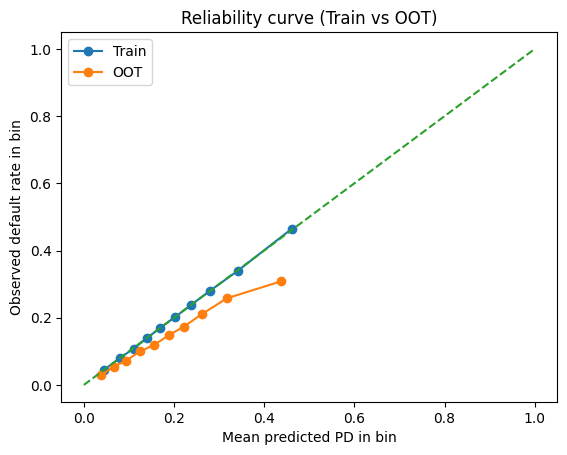

,bin,pred_mean,obs_rate,count
0,0,0.043693,0.043961,116330
1,1,0.079976,0.079825,116329
2,2,0.110271,0.107970,116329
3,3,0.139478,0.138528,116330
4,4,0.169834,0.170473,116329


,bin,pred_mean,obs_rate,count
0,0,0.038519,0.028184,4719
1,1,0.065825,0.054461,4719
2,2,0.093680,0.072261,4719
3,3,0.124221,0.099597,4719
4,4,0.156211,0.119305,4719


In [14]:
import matplotlib.pyplot as plt

def reliability_curve(y_true, p_pred, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred)

    bins = np.quantile(p_pred, np.linspace(0, 1, n_bins + 1))
    bins[0] = -1.0
    bins[-1] = 2.0

    idx = np.digitize(p_pred, bins) - 1
    out = []
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        out.append({
            "bin": b,
            "pred_mean": float(p_pred[mask].mean()),
            "obs_rate": float(y_true[mask].mean()),
            "count": int(mask.sum())
        })
    return pd.DataFrame(out)

rc_train = reliability_curve(train[TARGET_COL].values, pd_train, n_bins=10)
rc_oot   = reliability_curve(oot[TARGET_COL].values, pd_oot, n_bins=10)

plt.figure()
plt.plot(rc_train["pred_mean"], rc_train["obs_rate"], marker="o")
plt.plot(rc_oot["pred_mean"], rc_oot["obs_rate"], marker="o")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Reliability curve (Train vs OOT)")
plt.xlabel("Mean predicted PD in bin")
plt.ylabel("Observed default rate in bin")
plt.legend(["Train", "OOT"])
plt.show()

display(rc_train.head())
display(rc_oot.head())

**Interpretation**
- Train curve is close to the diagonal → good calibration in-sample.
- OOT curve lies below the diagonal across bins → predicted PDs are systematically higher than observed defaults in 2018.

This matches the negative calibration intercept and slope < 1 in the OOT summary.

## Interpretability: logistic coefficients (top drivers)

For logistic regression:
- positive coefficient => increases log-odds of default
- negative coefficient => decreases log-odds of default

We extract feature names after preprocessing (including one-hot encoded categories)
and display largest-magnitude coefficients.

This is a standard validation artifact (model transparency).

In [9]:
# Extract feature names after preprocessing
pre = pipe.named_steps["preprocess"]
feat_names = pre.get_feature_names_out()

coefs = pipe.named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df.sort_values("abs_coef", ascending=False).head(25)

,feature,coef,abs_coef
16,grade_A,-1.398750,1.398750
23,sub_grade_A1,-0.781503,0.781503
22,grade_G,0.735722,0.735722
17,grade_B,-0.662900,0.662900
21,grade_F,0.614943,0.614943
14,term_ 36 months,-0.509741,0.509741
24,sub_grade_A2,-0.414255,0.414255
20,grade_E,0.407884,0.407884
28,sub_grade_B1,-0.377344,0.377344
10,installment,0.346038,0.346038


**Coefficient interpretation notes**
- Logistic coefficients operate on **log-odds**: a +coef increases default odds, a -coef decreases them.
- Categorical variables are one-hot encoded; coefficients compare each category against the (implicit) reference behavior.
- `grade` / `sub_grade` are LendingClub internal risk ratings (strong predictors). They are useful for a baseline,
  but they also summarize other variables and may reduce interpretability of the remaining features.

In [10]:
print("Top positive (higher default risk):")
display(coef_df.sort_values("coef", ascending=False).head(15)[["feature","coef"]])

print("Top negative (lower default risk):")
display(coef_df.sort_values("coef", ascending=True).head(15)[["feature","coef"]])

Top positive (higher default risk):


,feature,coef
22,grade_G,0.735722
21,grade_F,0.614943
20,grade_E,0.407884
10,installment,0.346038
88,purpose_small_business,0.226091
52,sub_grade_F5,0.205149
15,term_ 60 months,0.199326
47,sub_grade_E5,0.196426
51,sub_grade_F4,0.181751
55,sub_grade_G3,0.175374


Top negative (lower default risk):


,feature,coef
16,grade_A,-1.398750
23,sub_grade_A1,-0.781503
17,grade_B,-0.662900
14,term_ 36 months,-0.509741
24,sub_grade_A2,-0.414255
28,sub_grade_B1,-0.377344
70,home_ownership_MORTGAGE,-0.288533
29,sub_grade_B2,-0.280408
90,purpose_wedding,-0.271406
25,sub_grade_A3,-0.252227


**Sanity check**
The strongest coefficients align with credit intuition:
- worse grades (e.g., G/F/E) increase risk; better grades (A/B) reduce risk
- longer term (60 months) increases risk vs 36 months
- higher DTI tends to increase risk

This supports face validity (a key Model Risk requirement).

# Conclusions (Champion)

**Governance**
- Feature set follows a strict underwriting-time policy (no leakage fields as inputs).
- Missingness governance applied (>30% Train missing => excluded).

**Performance**
- Discrimination metrics (AUC/KS/PR-AUC, Top-K capture) are reported for Train and OOT.
- Drift is assessed via Train vs OOT comparison.

**Probability quality**
- Calibration slope/intercept and reliability curves indicate whether PDs can be used as probabilities.
- Any OOT miscalibration motivates recalibration and monitoring in production.

**Next step**
- Build the full validation suite notebook (PSI, drift tables, sensitivity, stress) and produce report-ready figures.